# Model Training, Cost Optimization & Selection

Trains baselines (dummy, logistic regression) and the two primary GBDT
candidates (LightGBM, XGBoost), then runs cost-sensitive threshold
optimization independently for each. Cost savings vs. a no-model baseline,
not AUC-ROC, decides the winner -- consistent with the project's decision
framework. Stacking and CNN-LSTM (Notebooks 04b/04c) are evaluated
separately on Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report, confusion_matrix
)
import lightgbm as lgb
import xgboost as xgb
import joblib

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120

# Load engineered dataset from Notebook 03
print('Loading engineered dataset...')
train = pd.read_parquet('../data/train_engineered.parquet')
print(f'Shape: {train.shape}')
print(f'Fraud rate: {train["isFraud"].mean():.2%}')
print(f'Memory: {train.memory_usage().sum() / 1024**2:.1f} MB')

Loading engineered dataset...
Shape: (590540, 455)
Fraud rate: 3.50%
Memory: 1083.6 MB


## Train/Test Split

Chronological 80/20 split (no shuffle): random shuffling would let the
model train on data from after the test period, leaking future information
and inflating validation scores relative to real deployment performance.


In [2]:
# ── Chronological Train/Test Split ────────────────────────────────────────────

# Sort by transaction time to preserve temporal order
train = train.sort_values('TransactionDT').reset_index(drop=True)

# Define features and target
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS = [c for c in DROP_COLS if c in train.columns]

# Drop object columns (not yet encoded)
obj_cols = train.select_dtypes('object').columns.tolist()
print(f'Dropping object columns: {obj_cols}')
DROP_COLS += obj_cols

FEATURES = [c for c in train.columns if c not in DROP_COLS]
print(f'Number of features: {len(FEATURES)}')

X = train[FEATURES]
y = train[TARGET]

# 80/20 chronological split
split_idx = int(len(train) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'\nTrain: {X_train.shape[0]:,} rows | Fraud rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape[0]:,} rows  | Fraud rate: {y_test.mean():.2%}')

# Class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f'\nscale_pos_weight: {SCALE_POS_WEIGHT:.1f} (neg/pos ratio)')

Dropping object columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
Number of features: 421

Train: 472,432 rows | Fraud rate: 3.51%
Test:  118,108 rows  | Fraud rate: 3.44%

scale_pos_weight: 27.5 (neg/pos ratio)


In [3]:
# ── Results tracker ───────────────────────────────────────────────────────────
# Store all model results here for final comparison table

results = {}

def evaluate_model(name, y_true, y_pred_proba, y_pred_binary=None):
    """Compute and store evaluation metrics for a model."""
    auc_roc = roc_auc_score(y_true, y_pred_proba)
    auc_pr  = average_precision_score(y_true, y_pred_proba)
    
    if y_pred_binary is None:
        y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    
    f1      = f1_score(y_true, y_pred_binary)
    recall  = (y_pred_binary[y_true == 1] == 1).mean()
    precision = (y_true[y_pred_binary == 1] == 1).mean() if y_pred_binary.sum() > 0 else 0
    
    results[name] = {
        'AUC-ROC': round(auc_roc, 4),
        'AUC-PR':  round(auc_pr, 4),
        'F1':      round(f1, 4),
        'Recall':  round(recall, 4),
        'Precision': round(precision, 4)
    }
    
    print(f'\n=== {name} ===')
    print(f'  AUC-ROC:   {auc_roc:.4f}')
    print(f'  AUC-PR:    {auc_pr:.4f}')
    print(f'  F1:        {f1:.4f}')
    print(f'  Recall:    {recall:.4f}')
    print(f'  Precision: {precision:.4f}')
    return results[name]

## Baselines

B0 (dummy) always predicts "no fraud" -- 96.5% accuracy but zero fraud
caught, the floor any useful model must beat. B1 (logistic regression) is
a simple linear baseline without UID aggregation features.

In [4]:
# ── B0: Dummy Classifier ──────────────────────────────────────────────────────

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# Dummy always predicts 0 -> proba is always [1.0, 0.0]
# AUC-ROC needs some variation, so we use predict_proba
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_pred  = dummy.predict(X_test)

print(f'Dummy always predicts: {dummy.predict(X_test[:5])}')
print(f'Accuracy: {(dummy_pred == y_test).mean():.2%} (misleading!)')
print(f'Fraud caught: {(dummy_pred[y_test == 1] == 1).sum()} / {(y_test == 1).sum()}')

evaluate_model('B0_Dummy', y_test, dummy_proba, dummy_pred)

Dummy always predicts: [0 0 0 0 0]
Accuracy: 96.56% (misleading!)
Fraud caught: 0 / 4064

=== B0_Dummy ===
  AUC-ROC:   0.5000
  AUC-PR:    0.0344
  F1:        0.0000
  Recall:    0.0000
  Precision: 0.0000


{'AUC-ROC': 0.5,
 'AUC-PR': 0.0344,
 'F1': 0.0,
 'Recall': np.float64(0.0),
 'Precision': 0}

In [5]:
# ── B1: Logistic Regression ───────────────────────────────────────────────────

# Scale features (LR requires normalized input)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_test_scaled  = scaler.transform(X_test.fillna(0))

lr = LogisticRegression(
    C=0.1,                          # L2 regularization
    class_weight='balanced',        # handles imbalance
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print('Training Logistic Regression...')
lr.fit(X_train_scaled, y_train)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred  = lr.predict(X_test_scaled)

evaluate_model('B1_LogisticRegression', y_test, lr_proba, lr_pred)

Training Logistic Regression...

=== B1_LogisticRegression ===
  AUC-ROC:   0.8257
  AUC-PR:    0.1764
  F1:        0.1803
  Recall:    0.7473
  Precision: 0.1025


{'AUC-ROC': 0.8257,
 'AUC-PR': 0.1764,
 'F1': 0.1803,
 'Recall': np.float64(0.7473),
 'Precision': np.float64(0.1025)}

## LightGBM

`scale_pos_weight` handles class imbalance natively; early stopping
prevents overfitting on the validation set.


In [ ]:
lgbm_params = {
    'objective':        'binary',
    'metric':           ['auc', 'average_precision'],
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       64,
    'max_depth':        -1,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1
}

lgbm_model = lgb.LGBMClassifier(**lgbm_params)

print('Training LightGBM...')
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_pred  = lgbm_model.predict(X_test)

evaluate_model('C1a_LightGBM', y_test, lgbm_proba, lgbm_pred)

# Save model
joblib.dump(lgbm_model, '../models/lgbm_model.pkl')
print('\nModel saved: models/lgbm_model.pkl')

Training LightGBM...
[100]	valid_0's auc: 0.915907	valid_0's average_precision: 0.505048
[200]	valid_0's auc: 0.920139	valid_0's average_precision: 0.541447

=== C1a_LightGBM ===
  AUC-ROC:   0.9204
  AUC-PR:    0.5375
  F1:        0.3510
  Recall:    0.7601
  Precision: 0.2282

Model saved: models/lgbm_model.pkl


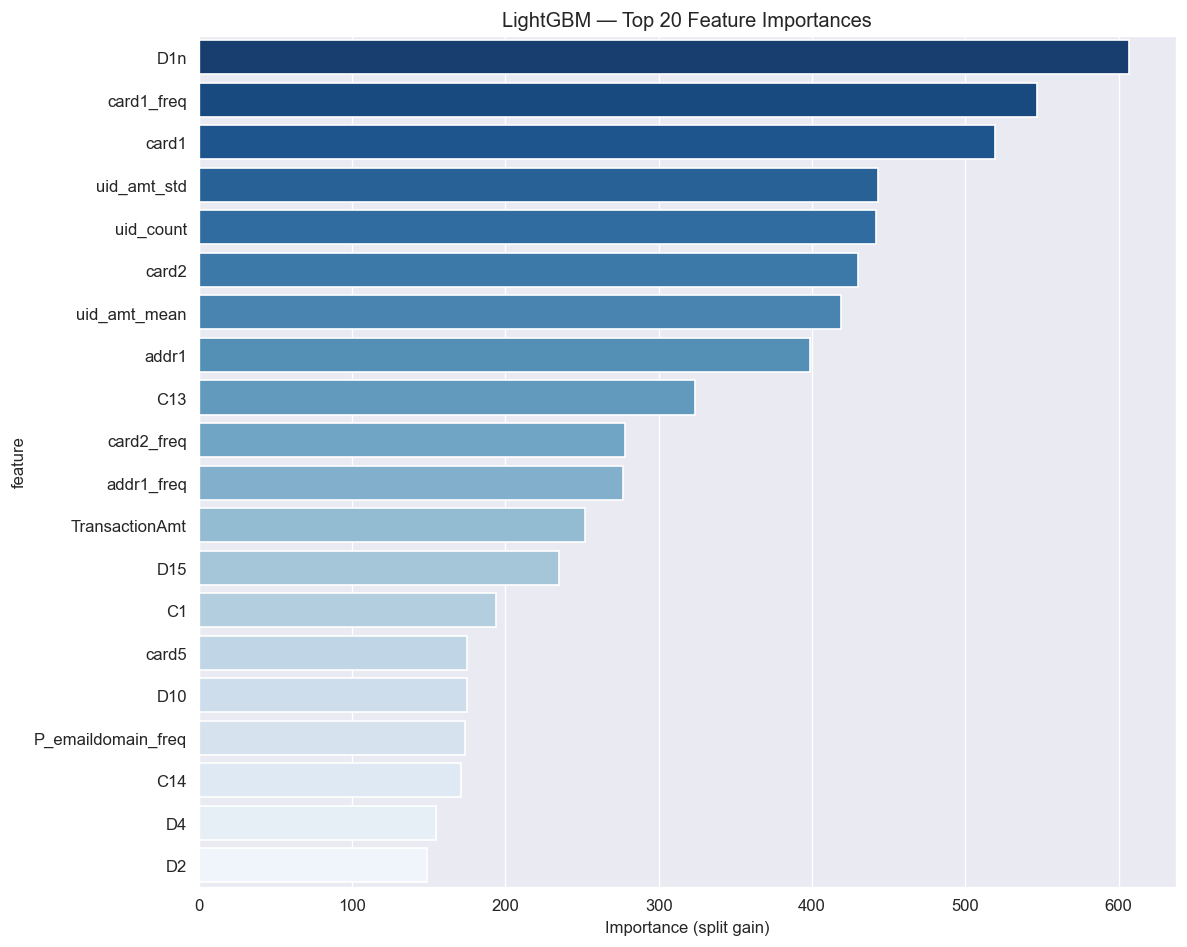

Top 10 features:
     feature  importance
         D1n         607
  card1_freq         547
       card1         519
 uid_amt_std         443
   uid_count         442
       card2         430
uid_amt_mean         419
       addr1         399
         C13         324
  card2_freq         278


In [7]:
# ── LightGBM Feature Importance ───────────────────────────────────────────────

feat_imp = pd.DataFrame({
    'feature':    FEATURES,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature',
            palette='Blues_r', ax=ax)
ax.set_title('LightGBM — Top 20 Feature Importances')
ax.set_xlabel('Importance (split gain)')
plt.tight_layout()
plt.savefig('../reports/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string(index=False))

## XGBoost

Second GBDT candidate. Slightly slower than LightGBM but often more robust on smaller datasets.
Key question: does XGBoost outperform LightGBM on this dataset?


In [ ]:
xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      ['auc', 'aucpr'],
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'max_depth':        6,
    'min_child_weight': 5,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'n_jobs':           -1,
    'tree_method':      'hist',   # fast histogram method, no GPU needed
    'early_stopping_rounds': 50 
}

xgb_model = xgb.XGBClassifier(**xgb_params)

print('Training XGBoost...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

evaluate_model('C1b_XGBoost', y_test, xgb_proba, xgb_pred)

joblib.dump(xgb_model, '../models/xgb_model.pkl')
print('\nModel saved: models/xgb_model.pkl')

Training XGBoost...
[0]	validation_0-auc:0.82533	validation_0-aucpr:0.29728
[100]	validation_0-auc:0.89485	validation_0-aucpr:0.48579
[200]	validation_0-auc:0.90797	validation_0-aucpr:0.51714
[300]	validation_0-auc:0.91279	validation_0-aucpr:0.53291
[400]	validation_0-auc:0.91438	validation_0-aucpr:0.54463
[500]	validation_0-auc:0.91508	validation_0-aucpr:0.55294
[600]	validation_0-auc:0.91597	validation_0-aucpr:0.56099
[700]	validation_0-auc:0.91628	validation_0-aucpr:0.56828
[800]	validation_0-auc:0.91649	validation_0-aucpr:0.57535
[900]	validation_0-auc:0.91590	validation_0-aucpr:0.57658
[999]	validation_0-auc:0.91495	validation_0-aucpr:0.57831

=== C1b_XGBoost ===
  AUC-ROC:   0.9155
  AUC-PR:    0.5784
  F1:        0.4738
  Recall:    0.6619
  Precision: 0.3689

Model saved: models/xgb_model.pkl


## Results Comparison Table


In [ ]:
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

# Add Colab results manually when available
colab_results = {
    'C2_Stacking':  {'AUC-ROC': None, 'AUC-PR': None, 'F1': None, 'Recall': None, 'Precision': None},
    'C3_CNN_LSTM':  {'AUC-ROC': None, 'AUC-PR': None, 'F1': None, 'Recall': None, 'Precision': None},
}
colab_df = pd.DataFrame(colab_results).T
colab_df.index.name = 'Model'

# External benchmark
benchmark = pd.DataFrame({
    'Moradi_et_al_2025': {'AUC-ROC': 0.918, 'AUC-PR': 0.891, 'F1': None, 'Recall': None, 'Precision': None}
}).T

all_results = pd.concat([results_df, colab_df, benchmark])
print('\n=== FULL MODEL COMPARISON ===')
print(all_results.to_string())

# Highlight best local model
local_results = results_df.drop('B0_Dummy', errors='ignore')
if len(local_results) > 0:
    best_model = local_results['AUC-ROC'].idxmax()
    print(f'\nBest local model by AUC-ROC: {best_model}')


=== FULL MODEL COMPARISON ===
                       AUC-ROC  AUC-PR      F1  Recall  Precision
B0_Dummy                0.5000  0.0344  0.0000  0.0000     0.0000
B1_LogisticRegression   0.8257  0.1764  0.1803  0.7473     0.1025
C1a_LightGBM            0.9204  0.5375  0.3510  0.7601     0.2282
C1b_XGBoost             0.9155  0.5784  0.4738  0.6619     0.3689
C2_Stacking                NaN     NaN     NaN     NaN        NaN
C3_CNN_LSTM                NaN     NaN     NaN     NaN        NaN
Moradi_et_al_2025       0.9180  0.8910     NaN     NaN        NaN

Best local model by AUC-ROC: C1a_LightGBM


## Cost-Sensitive Threshold Optimization

Default threshold (0.5) optimizes for accuracy, which is meaningless under
3.5% class imbalance. The decision threshold is instead swept to minimize
total expected cost (FN = transaction amount, FP = $10), run independently
for each candidate so the winner is chosen by cost savings -- not AUC-ROC.


In [ ]:
COST_FP = 10     # False Positive: customer friction ($)
COST_FN = 150    # False Negative: average fraud loss ($) -- informational only,
                 # actual FN cost below uses the real TransactionAmt per row

test_amounts = train['TransactionAmt'].iloc[split_idx:].values
no_model_cost = test_amounts[y_test.values == 1].sum()

def optimize_threshold(proba, y_true, amounts, cost_fp=10):
    """Sweep thresholds, return (thresholds, total_costs, f1_scores, optimal_idx)."""
    thresholds  = np.arange(0.05, 0.95, 0.01)
    total_costs = []
    f1_scores_sweep = []

    for thresh in thresholds:
        preds = (proba >= thresh).astype(int)
        fn_mask = (preds == 0) & (y_true.values == 1)
        fn_cost = amounts[fn_mask].sum()
        fp_mask = (preds == 1) & (y_true.values == 0)
        fp_cost = fp_mask.sum() * cost_fp
        total_costs.append(fn_cost + fp_cost)
        f1_scores_sweep.append(f1_score(y_true, preds))

    total_costs = np.array(total_costs)
    optimal_idx = np.argmin(total_costs)
    return thresholds, total_costs, f1_scores_sweep, optimal_idx

cost_results = {}

for model_name, proba in [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba)]:
    thresholds, total_costs, f1_scores_sweep, optimal_idx = optimize_threshold(
        proba, y_test, test_amounts, COST_FP
    )
    optimal_thresh = thresholds[optimal_idx]
    optimal_cost   = total_costs[optimal_idx]
    savings        = no_model_cost - optimal_cost
    savings_pct    = savings / no_model_cost * 100

    cost_results[model_name] = {
        'thresholds': thresholds, 'total_costs': total_costs,
        'f1_scores_sweep': f1_scores_sweep, 'optimal_idx': optimal_idx,
        'optimal_thresh': optimal_thresh, 'optimal_cost': optimal_cost,
        'savings': savings, 'savings_pct': savings_pct, 'proba': proba
    }

    print(f'=== {model_name} ===')
    print(f'  Optimal threshold:    {optimal_thresh:.2f}')
    print(f'  Total cost at optimal: ${optimal_cost:,.0f}')
    print(f'  Savings:               ${savings:,.0f} ({savings_pct:.1f}%)')
    print()

print(f'No-model baseline cost: ${no_model_cost:,.0f}')
print()

# Final model selection: whichever has higher cost savings wins, since cost
# savings (not AUC-ROC) is this project\'s primary, business-facing metric.
winner = max(cost_results, key=lambda k: cost_results[k]['savings'])
print(f'>>> WINNER by cost savings: {winner} '
      f'(${cost_results[winner]["savings"]:,.0f}, {cost_results[winner]["savings_pct"]:.1f}%)')

best_proba      = cost_results[winner]['proba']
optimal_thresh  = cost_results[winner]['optimal_thresh']
optimal_cost    = cost_results[winner]['optimal_cost']
savings         = cost_results[winner]['savings']
savings_pct     = cost_results[winner]['savings_pct']
thresholds      = cost_results[winner]['thresholds']
total_costs     = cost_results[winner]['total_costs']
f1_scores_sweep = cost_results[winner]['f1_scores_sweep']


=== LightGBM ===
  Optimal threshold:    0.51
  Total cost at optimal: $248,895
  Savings:               $361,039 (59.2%)

=== XGBoost ===
  Optimal threshold:    0.33
  Total cost at optimal: $246,827
  Savings:               $363,107 (59.5%)

No-model baseline cost: $609,934

>>> WINNER by cost savings: XGBoost ($363,107, 59.5%)


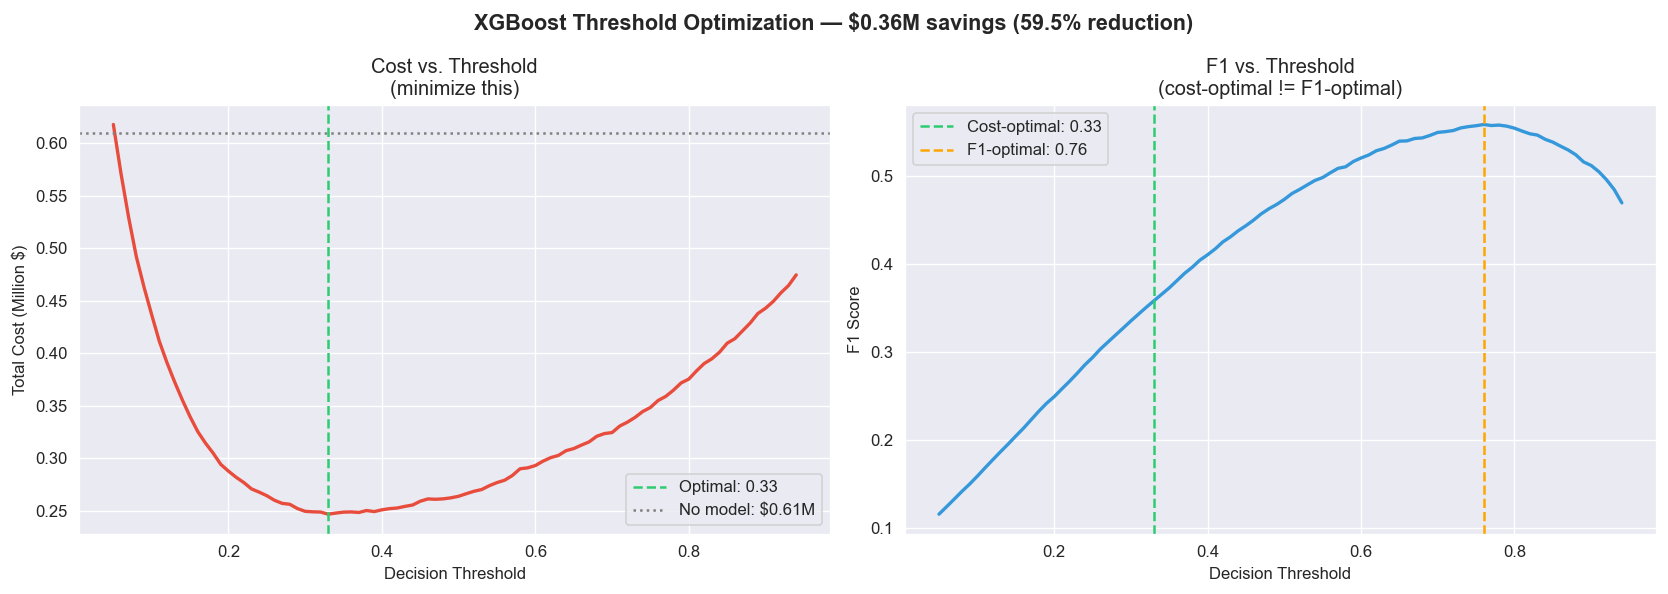

Saved: reports/threshold_optimization.png

Final model selected by cost savings: XGBoost


In [11]:
# ── Plot: Cost vs Threshold (winning model) ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total cost vs threshold
axes[0].plot(thresholds, total_costs / 1e6, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Optimal: {optimal_thresh:.2f}')
axes[0].axhline(no_model_cost / 1e6, color='gray', linestyle=':',
                label=f'No model: ${no_model_cost/1e6:.2f}M')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (Million $)')
axes[0].set_title('Cost vs. Threshold\n(minimize this)')
axes[0].legend()

# Right: F1 vs threshold
axes[1].plot(thresholds, f1_scores_sweep, color='#3498db', linewidth=2)
axes[1].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Cost-optimal: {optimal_thresh:.2f}')
f1_optimal_idx = np.argmax(f1_scores_sweep)
axes[1].axvline(thresholds[f1_optimal_idx], color='orange', linestyle='--',
                label=f'F1-optimal: {thresholds[f1_optimal_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs. Threshold\n(cost-optimal != F1-optimal)')
axes[1].legend()

plt.suptitle(f'{winner} Threshold Optimization — ${savings/1e6:.2f}M savings ({savings_pct:.1f}% reduction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/threshold_optimization.png')
print(f'\nFinal model selected by cost savings: {winner}')


=== Final Performance at Optimal Threshold (0.33) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.91      0.95    114044
       Fraud       0.23      0.76      0.36      4064

    accuracy                           0.91    118108
   macro avg       0.61      0.84      0.65    118108
weighted avg       0.96      0.91      0.93    118108



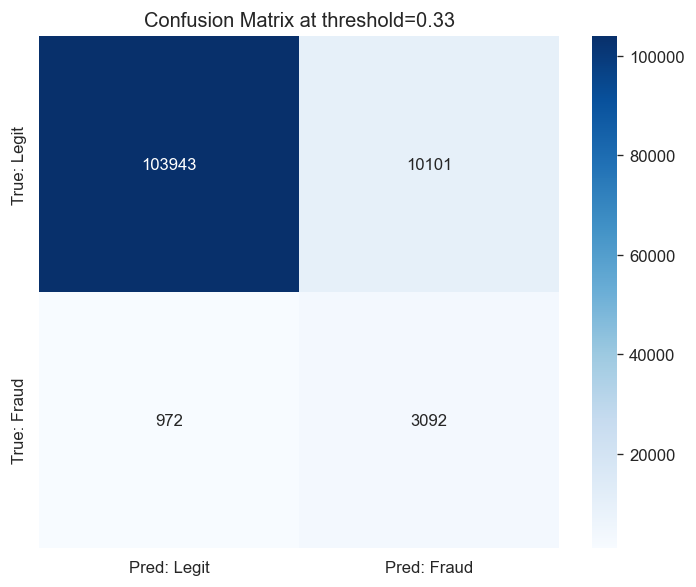

: 

In [ ]:
# ── Final evaluation at optimal threshold ─────────────────────────────────────

optimal_preds = (best_proba >= optimal_thresh).astype(int)

print(f'=== Final Performance at Optimal Threshold ({optimal_thresh:.2f}) ===')
print(classification_report(y_test, optimal_preds,
                             target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_test, optimal_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'], ax=ax)
ax.set_title(f'Confusion Matrix at threshold={optimal_thresh:.2f}')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()